In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("retail_sales_dataset.csv")


print("Everything is working!")

Everything is working!


In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display charts inside the notebook
%matplotlib inline

# Set chart style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [68]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles in this folder:")
print(os.listdir())

Current folder:
c:\Users\ACER\OneDrive\Documents\OIBSIP\DataAnalytics-L1-EDARetailSales

Files in this folder:
['README.md', 'retail_sales_dataset.csv', 'Retail_Sales_EDA.ipynb']


In [69]:
import os

print(os.getcwd())

c:\Users\ACER\OneDrive\Documents\OIBSIP\DataAnalytics-L1-EDARetailSales


In [70]:
import os

print(os.listdir())


['README.md', 'retail_sales_dataset.csv', 'Retail_Sales_EDA.ipynb']


In [71]:
#initial inspection
print("Shape of the dataset:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape of the dataset: (1000, 9)

Column Names:
Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='str')

Data Types:
Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object

Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [72]:
#descriptive statistics 
df.describe()
df.mean(numeric_only=True)
df.median(numeric_only=True)
df.mode().iloc[0]
df.std(numeric_only=True)

Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64

In [73]:
# time series analysis:Create Month and Quarter columns
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
df["Month"] = df["Date"].dt.to_period("M")
df["Quarter"] = df["Date"].dt.to_period("Q")

print(df[["Date", "Month", "Quarter"]].head())
print(df["Date"].dtype)
print(df["Date"].isnull().sum())

        Date    Month Quarter
0 2023-11-24  2023-11  2023Q4
1 2023-02-27  2023-02  2023Q1
2 2023-01-13  2023-01  2023Q1
3 2023-05-21  2023-05  2023Q2
4 2023-05-06  2023-05  2023Q2
datetime64[us]
0


C:\Users\ACER\AppData\Local\Temp\ipykernel_19132\1196986126.py:2: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")


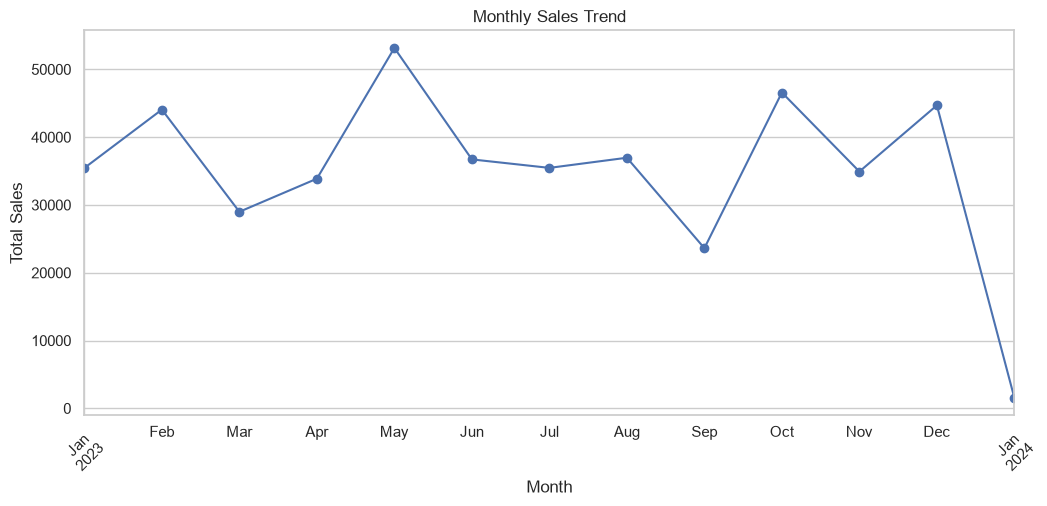

In [74]:
monthly_sales = df.groupby("Month")["Total Amount"].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot(marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

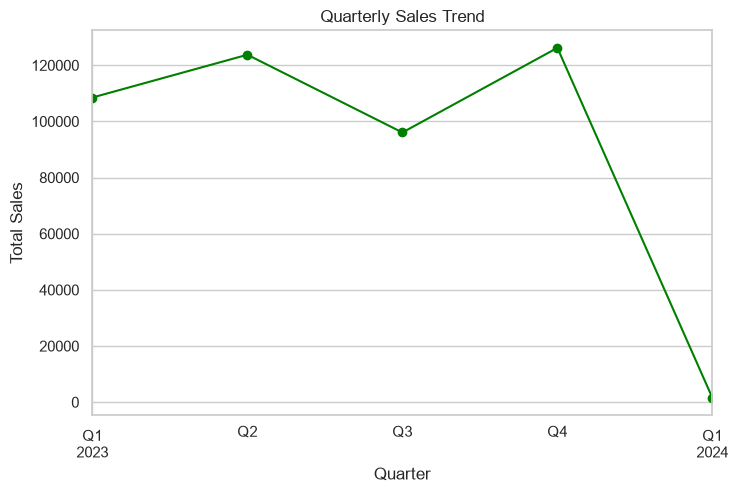

In [75]:
quarterly_sales = df.groupby("Quarter")["Total Amount"].sum()

plt.figure(figsize=(8,5))
quarterly_sales.plot(marker="o", color="green")
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

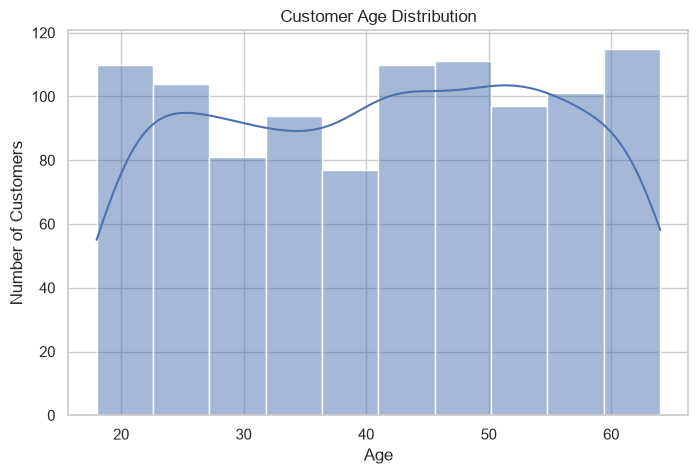

In [ ]:
#customer age distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=10, kde=True)
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

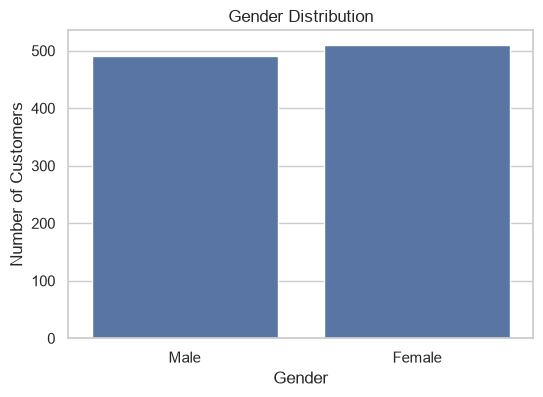

In [77]:
#gender breakdown
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Gender")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

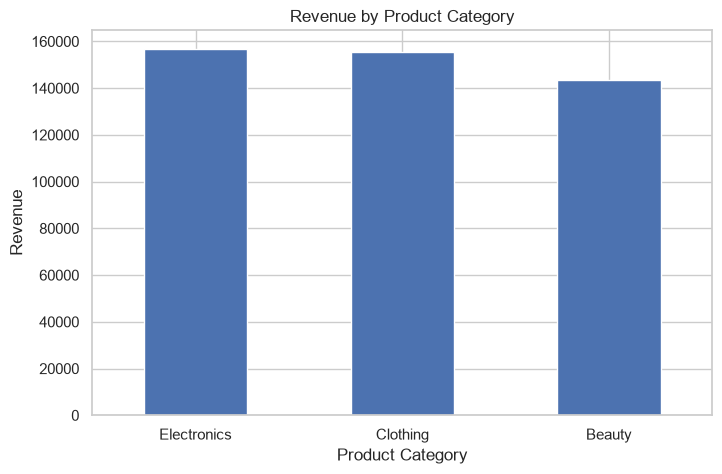

In [78]:
#product analysis
category_sales = df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")
plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.show()

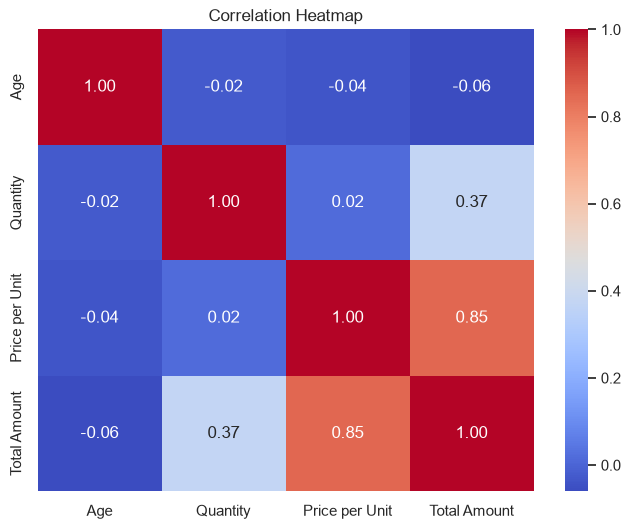

In [79]:
#correlation heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    df[["Age", "Quantity", "Price per Unit", "Total Amount"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

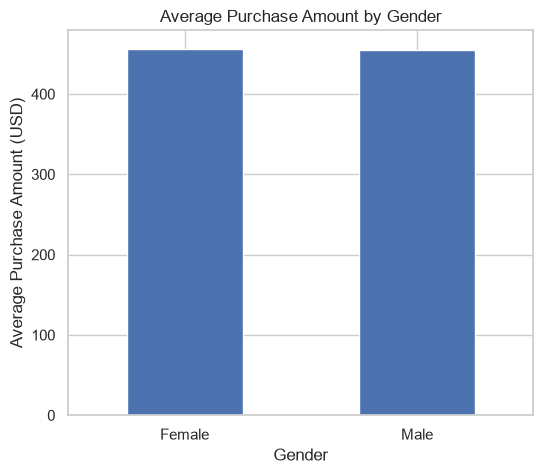

In [80]:
gender_sales = df.groupby("Gender")["Total Amount"].mean()

plt.figure(figsize=(6,5))
gender_sales.plot(kind="bar")
plt.title("Average Purchase Amount by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Purchase Amount (USD)")
plt.xticks(rotation=0)
plt.show()